In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import numpy as np

In [2]:
class SingleRNN(nn.Module):
    def __init__(self, n_inputs, n_neurons):
        super(SingleRNN, self).__init__()

        self.Wx = torch.randn(n_inputs, n_neurons) # 4 X 1
        self.Wy = torch.randn(n_neurons, n_neurons) # 1 X 1

        self.b = torch.zeros(1, n_neurons) # 1 X 4

    def forward(self, X0, X1):
        self.Y0 = torch.tanh(torch.mm(X0, self.Wx) + self.b) # 4 X 1

        self.Y1 = torch.tanh(torch.mm(self.Y0, self.Wy) +
                            torch.mm(X1, self.Wx) + self.b) # 4 X 1

        return self.Y0, self.Y1

In [3]:
N_INPUT = 4
N_NEURONS = 1

X0_batch = torch.tensor([[0,1,2,0], [3,4,5,0],
                         [6,7,8,0], [9,0,1,0]],
                        dtype = torch.float) #t=0 => 4 X 4

X1_batch = torch.tensor([[9,8,7,0], [0,0,0,0],
                         [6,5,4,0], [3,2,1,0]],
                        dtype = torch.float) #t=1 => 4 X 4

model = SingleRNN(N_INPUT, N_NEURONS)

Y0_val, Y1_val = model(X0_batch, X1_batch)

In [4]:
print(Y0_val)
print(Y1_val)

tensor([[-0.9033],
        [-1.0000],
        [-1.0000],
        [-1.0000]])
tensor([[-1.0000],
        [-0.3359],
        [-1.0000],
        [-1.0000]])


In [5]:
class BasicRNN(nn.Module):
    def __init__(self, n_inputs, n_neurons):
        super(BasicRNN, self).__init__()

        self.Wx = torch.randn(n_inputs, n_neurons) # n_inputs X n_neurons
        self.Wy = torch.randn(n_neurons, n_neurons) # n_neurons X n_neurons

        self.b = torch.zeros(1, n_neurons) # 1 X n_neurons

    def forward(self, X0, X1):
        self.Y0 = torch.tanh(torch.mm(X0, self.Wx) + self.b) # batch_size X n_neurons

        self.Y1 = torch.tanh(torch.mm(self.Y0, self.Wy) +
                            torch.mm(X1, self.Wx) + self.b) # batch_size X n_neurons

        return self.Y0, self.Y1

In [6]:
N_INPUT = 3 # number of features in input
N_NEURONS = 5 # number of units in layer

X0_batch = torch.tensor([[0,1,2], [3,4,5],
                         [6,7,8], [9,0,1]],
                        dtype = torch.float) #t=0 => 4 X 3

X1_batch = torch.tensor([[9,8,7], [0,0,0],
                         [6,5,4], [3,2,1]],
                        dtype = torch.float) #t=1 => 4 X 3

model = BasicRNN(N_INPUT, N_NEURONS)

Y0_val, Y1_val = model(X0_batch, X1_batch)

In [7]:
print(Y0_val)
print(Y1_val)

tensor([[ 0.9034,  0.9883, -0.0758,  0.9997, -0.9995],
        [ 1.0000,  1.0000, -0.9996,  1.0000, -1.0000],
        [ 1.0000,  1.0000, -1.0000,  1.0000, -1.0000],
        [ 1.0000,  1.0000, -1.0000, -0.9117, -0.9994]])
tensor([[ 1.0000,  1.0000, -1.0000,  1.0000, -1.0000],
        [-0.5634, -0.1652,  0.7652,  0.8336,  0.8589],
        [ 1.0000,  1.0000, -1.0000,  1.0000, -1.0000],
        [ 1.0000,  0.9998, -0.9981,  0.9983, -1.0000]])


In [8]:
rnn = nn.RNNCell(3, 5) # n_input X n_neurons

X_batch = torch.tensor([[[0,1,2], [3,4,5],
                         [6,7,8], [9,0,1]],
                        [[9,8,7], [0,0,0],
                         [6,5,4], [3,2,1]]
                       ], dtype = torch.float) # X0 and X1

hx = torch.randn(4, 5) # m X n_neurons
output = []

# for each time step
for i in range(2):
    hx = rnn(X_batch[i], hx)
    output.append(hx)

print(output)

[tensor([[ 0.4507,  0.6861,  0.1839,  0.8449,  0.6851],
        [ 0.9139,  0.9757,  0.9989, -0.7192,  0.9966],
        [ 0.9995,  0.9964,  1.0000, -0.9376,  1.0000],
        [ 0.9954, -0.6732,  0.9981, -0.9988,  0.2458]],
       grad_fn=<TanhBackward0>), tensor([[ 0.9999,  0.9299,  0.9999, -0.9893,  1.0000],
        [-0.1267, -0.1832, -0.6121,  0.1469, -0.4696],
        [ 0.9911,  0.4796,  0.9928, -0.9750,  0.9971],
        [ 0.8180,  0.3333,  0.9165, -0.8804,  0.8639]],
       grad_fn=<TanhBackward0>)]


In [9]:
class CleanBasicRNN(nn.Module):
    def __init__(self, batch_size, n_inputs, n_neurons):
        super(CleanBasicRNN, self).__init__()

        self.rnn = nn.RNNCell(n_inputs, n_neurons)
        self.hx = torch.randn(batch_size, n_neurons) # initialize hidden state

    def forward(self, X):
        output = []

        # for each time step
        for i in range(2):
            self.hx = self.rnn(X[i], self.hx)
            output.append(self.hx)

        return output, self.hx

In [10]:
FIXED_BATCH_SIZE = 4 # our batch size is fixed for now
N_INPUT = 3
N_NEURONS = 5

X_batch = torch.tensor([[[0,1,2], [3,4,5],
                         [6,7,8], [9,0,1]],
                        [[9,8,7], [0,0,0],
                         [6,5,4], [3,2,1]]
                       ], dtype = torch.float) # X0 and X1


model = CleanBasicRNN(FIXED_BATCH_SIZE, N_INPUT, N_NEURONS)
output_val, states_val = model(X_batch)
print(output_val) # contains all output for all timesteps
print(states_val) # contain values for final state or final timestep, i.e., t=1

[tensor([[ 0.7802,  0.9167, -0.5800, -0.5729, -0.5680],
        [ 0.9861,  0.9916, -0.7777, -0.2732,  0.9143],
        [ 0.9888,  0.9993, -0.9639,  0.5455,  0.9904],
        [ 0.9998, -0.9905,  0.2985, -0.9024,  0.9992]],
       grad_fn=<TanhBackward0>), tensor([[ 0.9993,  0.9984, -0.9881, -0.5776,  0.9993],
        [ 0.4090,  0.7041, -0.4239, -0.2437,  0.5013],
        [ 0.9898,  0.9736, -0.9362, -0.3550,  0.9976],
        [ 0.9516,  0.3511, -0.8351, -0.9381,  0.8542]],
       grad_fn=<TanhBackward0>)]
tensor([[ 0.9993,  0.9984, -0.9881, -0.5776,  0.9993],
        [ 0.4090,  0.7041, -0.4239, -0.2437,  0.5013],
        [ 0.9898,  0.9736, -0.9362, -0.3550,  0.9976],
        [ 0.9516,  0.3511, -0.8351, -0.9381,  0.8542]],
       grad_fn=<TanhBackward0>)


In [16]:
pip uninstall torch torchvision torchaudio -y

Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Found existing installation: torchvision 0.26.0
Uninstalling torchvision-0.26.0:
  Successfully uninstalled torchvision-0.26.0
Note: you may need to restart the kernel to use updated packages.


In [17]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
   ---------------------------------------- 0.0/114.5 MB ? eta -:--:--
    --------------------------------------- 2.6/114.5 MB 16.7 MB/s eta 0:00:07
   -- ------------------------------------- 7.1/114.5 MB 19.0 MB/s eta 0:00:06
   --- ------------------------------------ 9.2/114.5 MB 19.7 MB/s eta 0:00:06
   --- ------------------------------------ 10.2/114.5 MB 13.9 MB/s eta 0:00:08
   --- ------------------------------------ 10.2/114.5 MB 13.9 MB/s eta 0:00:08
   --- ------------------------------------ 10.7/114.5 MB 8.8 MB/s eta 0:00:12
   ---- ----------------------------------- 12.3/114.5 MB 9.2 MB/s eta 0:00:12
   ---- ----------------------------------- 12.3/114.5 MB 9.2 MB/s eta 0:00:12
   ---- ----------------------------------- 14.2/114.5 MB 7.7 MB/s eta 0:00:13
   ----- ---------------------------------- 14.7/114.5 MB 7.0 MB/s eta 0:00:15
   ----- ---------------------------------- 15.5/114.5 MB 6.7 MB/s eta 0:00:15
 


[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import sys
print(sys.executable)

C:\Users\sumai\AppData\Local\Programs\Python\Python312\python.exe


In [2]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu



[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torchvision
import torchvision.transforms as transforms

In [3]:
BATCH_SIZE = 64

# list all transformations
transform = transforms.Compose(
    [transforms.ToTensor()])

# download and load training dataset
trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE,
                                          shuffle=True, num_workers=2)

# download and load testing dataset
testset = torchvision.datasets.MNIST(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE,
                                         shuffle=False, num_workers=2)

100%|█████████████████████████████████| 9.91M/9.91M [00:09<00:00, 1.02MB/s]
100%|██████████████████████████████████| 28.9k/28.9k [00:00<00:00, 107kB/s]
100%|██████████████████████████████████| 1.65M/1.65M [00:01<00:00, 865kB/s]
100%|█████████████████████████████████████████| 4.54k/4.54k [00:00<?, ?B/s]


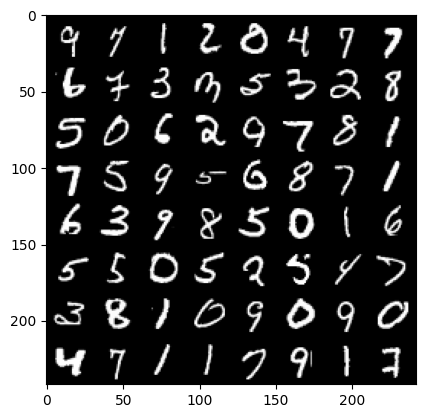

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image
def imshow(img):
    #img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))

In [5]:
# parameters
N_STEPS = 28
N_INPUTS = 28
N_NEURONS = 150
N_OUTPUTS = 10
N_EPHOCS = 10

In [7]:
import torch
import torch.nn as nn
class ImageRNN(nn.Module):
    def __init__(self, batch_size, n_steps, n_inputs, n_neurons, n_outputs):
        super(ImageRNN, self).__init__()

        self.n_neurons = n_neurons
        self.batch_size = batch_size
        self.n_steps = n_steps
        self.n_inputs = n_inputs
        self.n_outputs = n_outputs

        self.basic_rnn = nn.RNN(self.n_inputs, self.n_neurons)

        self.FC = nn.Linear(self.n_neurons, self.n_outputs)

    def init_hidden(self,):
        # (num_layers, batch_size, n_neurons)
        return (torch.zeros(1, self.batch_size, self.n_neurons))

    def forward(self, X):
        # transforms X to dimensions: n_steps X batch_size X n_inputs
        X = X.permute(1, 0, 2)

        self.batch_size = X.size(1)
        self.hidden = self.init_hidden()

        # lstm_out => n_steps, batch_size, n_neurons (hidden states for each time step)
        # self.hidden => 1, batch_size, n_neurons (final state from each lstm_out)
        lstm_out, self.hidden = self.basic_rnn(X, self.hidden)
        out = self.FC(self.hidden)

        return out.view(-1, self.n_outputs) # batch_size X n_output

In [8]:
dataiter = iter(trainloader)
images, labels = next(dataiter)
model = ImageRNN(BATCH_SIZE, N_STEPS, N_INPUTS, N_NEURONS, N_OUTPUTS)
logits = model(images.view(-1, 28,28))
print(logits[0:10])

tensor([[-0.0175, -0.1273, -0.0367, -0.0789,  0.0209, -0.0200,  0.0726,  0.1641,
          0.0496,  0.0348],
        [ 0.0087, -0.1262, -0.0271, -0.0951, -0.0200, -0.0220,  0.1185,  0.1126,
          0.0441,  0.0222],
        [ 0.0070, -0.1324, -0.0258, -0.0837, -0.0100, -0.0178,  0.0921,  0.1144,
          0.0326,  0.0232],
        [ 0.0124, -0.1243, -0.0230, -0.0964, -0.0108, -0.0247,  0.1041,  0.1086,
          0.0372,  0.0219],
        [ 0.0166, -0.1305, -0.0336, -0.0833, -0.0133, -0.0202,  0.0948,  0.0914,
          0.0335,  0.0122],
        [ 0.0387, -0.1425, -0.0371, -0.0818, -0.0113, -0.0256,  0.0941,  0.1010,
          0.0424,  0.0164],
        [ 0.0228, -0.1285, -0.0237, -0.0952, -0.0090, -0.0254,  0.0998,  0.0909,
          0.0363,  0.0340],
        [ 0.0171, -0.1259, -0.0227, -0.0935, -0.0118, -0.0303,  0.1034,  0.1091,
          0.0405,  0.0180],
        [ 0.0071, -0.1325, -0.0328, -0.0825, -0.0016, -0.0189,  0.0797,  0.1085,
          0.0283,  0.0136],
        [ 0.0138, -

In [9]:
import torch.optim as optim

# Device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Model instance
model = ImageRNN(BATCH_SIZE, N_STEPS, N_INPUTS, N_NEURONS, N_OUTPUTS)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def get_accuracy(logit, target, batch_size):
    ''' Obtain accuracy for training round '''
    corrects = (torch.max(logit, 1)[1].view(target.size()).data == target.data).sum()
    accuracy = 100.0 * corrects/batch_size
    return accuracy.item()

In [10]:
for epoch in range(N_EPHOCS):  # loop over the dataset multiple times
    train_running_loss = 0.0
    train_acc = 0.0
    model.train()

    # TRAINING ROUND
    for i, data in enumerate(trainloader):
         # zero the parameter gradients
        optimizer.zero_grad()

        # reset hidden states
        model.hidden = model.init_hidden()

        # get the inputs
        inputs, labels = data
        inputs = inputs.view(-1, 28,28)

        # forward + backward + optimize
        outputs = model(inputs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_running_loss += loss.detach().item()
        train_acc += get_accuracy(outputs, labels, BATCH_SIZE)

    model.eval()
    print('Epoch:  %d | Loss: %.4f | Train Accuracy: %.2f'
          %(epoch, train_running_loss / i, train_acc/i))

Epoch:  0 | Loss: 0.7773 | Train Accuracy: 74.20
Epoch:  1 | Loss: 0.3260 | Train Accuracy: 90.45
Epoch:  2 | Loss: 0.2444 | Train Accuracy: 92.96
Epoch:  3 | Loss: 0.2037 | Train Accuracy: 94.24
Epoch:  4 | Loss: 0.1806 | Train Accuracy: 94.95
Epoch:  5 | Loss: 0.1562 | Train Accuracy: 95.63
Epoch:  6 | Loss: 0.1446 | Train Accuracy: 95.88
Epoch:  7 | Loss: 0.1364 | Train Accuracy: 96.11
Epoch:  8 | Loss: 0.1269 | Train Accuracy: 96.54
Epoch:  9 | Loss: 0.1191 | Train Accuracy: 96.69


In [11]:
test_acc = 0.0
for i, data in enumerate(testloader, 0):
    inputs, labels = data
    inputs = inputs.view(-1, 28, 28)

    outputs = model(inputs)

    test_acc += get_accuracy(outputs, labels, BATCH_SIZE)

print('Test Accuracy: %.2f'%( test_acc/i))

Test Accuracy: 96.77
